In [128]:
from src.model import DiseaseModel
import config

import matplotlib.pyplot as plt
import pandas as pd

In [129]:
# Change these model parameters for different outputs
START_POPULATION = 1000
BETA = 10
SIGMA = 1
N_STEPS_MODEL = 10 # Number of time steps to run the model
OUTPUT_FILE_NAME = "output" # File extension not required. The output file will be saved to data folder
NO_INITIAL_INFECTIONS = 1

NO_RUNS = 10 # Number of times to run the model

In [130]:
# Running the model
for run_no in range(1, NO_RUNS + 1):
    starter_model = DiseaseModel(
        tot_pop=START_POPULATION, 
        beta= BETA, 
        sigma= SIGMA, 
        no_initial_infc=NO_INITIAL_INFECTIONS, 
        output_file_name=f"{OUTPUT_FILE_NAME}_{run_no}"
    )
    # Run the model for N_STEPS_MODEL time steps
    starter_model.run_until(N_STEPS_MODEL)

## Plots

(0.0, 1050.0)

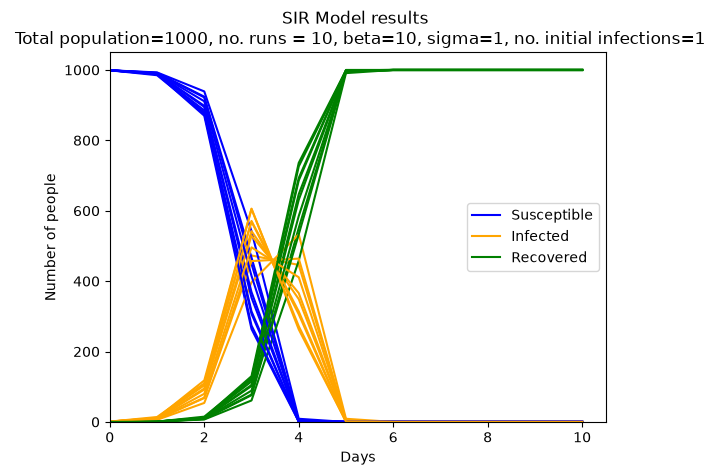

In [131]:
fig, ax = plt.subplots()

# For each run, adding plots of SIR population to the same figure
for run_no in range(1, NO_RUNS + 1):
    df = pd.read_csv(f'{config.OUTPUT_DIR}{OUTPUT_FILE_NAME}_{run_no}.csv', )

    # Adding legend label only for model run number 1 to avoid duplication of legend entries
    df.plot(x="tick", y="tot_sus", ax=ax, label="Susceptible" if run_no == 1 else "", color=config.DICT_COLOR_AGENTS[config.State.SUSCEPTIBLE])
    df.plot(x="tick", y="tot_inf", ax=ax, label="Infected" if run_no == 1 else "", color=config.DICT_COLOR_AGENTS[config.State.INFECTED])
    df.plot(x="tick", y="tot_rec", ax=ax, label="Recovered" if run_no == 1 else "", color=config.DICT_COLOR_AGENTS[config.State.RECOVERED])


plt.legend(loc='right')
plt.title(f"SIR Model results \n Total population={START_POPULATION}, no. runs = {NO_RUNS}, beta={BETA}, sigma={SIGMA}, no. initial infections={NO_INITIAL_INFECTIONS}")
plt.ylabel("Number of people")
plt.xlabel("Days")
ax.set_xlim(0)
ax.set_ylim(0)